In [1]:
# ============================================================
# TunnelScope ML Prototype
# Cell 1: Imports and configuration
# ============================================================

import os
import warnings
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
os.makedirs("../models", exist_ok=True)

print("TunnelScope ML environment ready.")

TunnelScope ML environment ready.


In [2]:
# ============================================================
# Cell 2: Load datasets
# ============================================================

TRAIN_PATH = "../data/synthetic_ipsec_dataset.csv"
WEAK_PATH = "../data/demo_weak_tunnels.csv"
STRONG_PATH = "../data/demo_strong_tunnels.csv"

synthetic_df = pd.read_csv(TRAIN_PATH)
weak_df = pd.read_csv(WEAK_PATH)
strong_df = pd.read_csv(STRONG_PATH)

print("Synthetic dataset :", synthetic_df.shape)
print("Weak dataset      :", weak_df.shape)
print("Strong dataset    :", strong_df.shape)

Synthetic dataset : (200, 14)
Weak dataset      : (25, 14)
Strong dataset    : (25, 14)


In [3]:
# ============================================================
# Cell 3: Dataset inspection
# ============================================================

print("Columns:")
print(synthetic_df.columns.tolist())

print("\nMissing values:")
print(synthetic_df.isnull().sum())

print("\nSecurity verdict distribution:")
print(synthetic_df["security_verdict"].value_counts())

print("\nTraffic type distribution:")
print(synthetic_df["traffic_type"].value_counts())

print("\nDuplicate rows:")
print(synthetic_df.duplicated().sum())

Columns:
['sample_id', 'mode', 'encryption_algo', 'dh_group', 'pfs', 'ip_version', 'traffic_type', 'avg_packet_size_bytes', 'packet_rate_per_sec', 'session_duration_sec', 'burstiness_index', 'ike_handshake_time_ms', 'security_verdict', 'risk_score']

Missing values:
sample_id                0
mode                     0
encryption_algo          0
dh_group                 0
pfs                      0
ip_version               0
traffic_type             0
avg_packet_size_bytes    0
packet_rate_per_sec      0
session_duration_sec     0
burstiness_index         0
ike_handshake_time_ms    0
security_verdict         0
risk_score               0
dtype: int64

Security verdict distribution:
security_verdict
Medium    80
Weak      64
Strong    56
Name: count, dtype: int64

Traffic type distribution:
traffic_type
file_transfer      38
web_browsing       37
video_streaming    35
email              33
icmp               31
voip               26
Name: count, dtype: int64

Duplicate rows:
0


Columns:
['sample_id', 'mode', 'encryption_algo', 'dh_group', 'pfs', 'ip_version', 'traffic_type', 'avg_packet_size_bytes', 'packet_rate_per_sec', 'session_duration_sec', 'burstiness_index', 'ike_handshake_time_ms', 'security_verdict', 'risk_score']

Missing values:
sample_id                0
mode                     0
encryption_algo          0
dh_group                 0
pfs                      0
ip_version               0
traffic_type             0
avg_packet_size_bytes    0
packet_rate_per_sec      0
session_duration_sec     0
burstiness_index         0
ike_handshake_time_ms    0
security_verdict         0
risk_score               0
dtype: int64


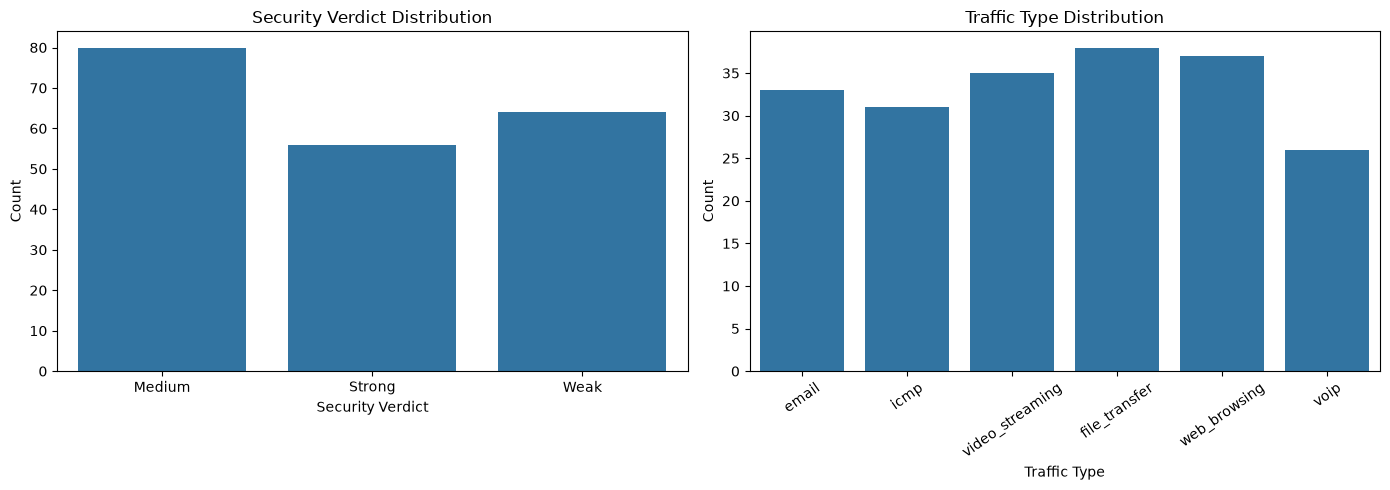


Security verdict distribution:
security_verdict
Medium    80
Weak      64
Strong    56
Name: count, dtype: int64

Traffic type distribution:
traffic_type
file_transfer      38
web_browsing       37
video_streaming    35
email              33
icmp               31
voip               26
Name: count, dtype: int64

Duplicate rows:
0


In [4]:
# ============================================================
# Cell 3: Dataset inspection
# ============================================================

print("Columns:")
print(synthetic_df.columns.tolist())

print("\nMissing values:")
print(synthetic_df.isnull().sum())
# ============================================================
# Cell 4: Class distributions
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(
    data=synthetic_df,
    x="security_verdict",
    ax=axes[0]
)
axes[0].set_title("Security Verdict Distribution")
axes[0].set_xlabel("Security Verdict")
axes[0].set_ylabel("Count")

sns.countplot(
    data=synthetic_df,
    x="traffic_type",
    ax=axes[1]
)
axes[1].set_title("Traffic Type Distribution")
axes[1].set_xlabel("Traffic Type")
axes[1].set_ylabel("Count")
axes[1].tick_params(axis="x", rotation=35)

plt.tight_layout()
plt.show()
print("\nSecurity verdict distribution:")
print(synthetic_df["security_verdict"].value_counts())

print("\nTraffic type distribution:")
print(synthetic_df["traffic_type"].value_counts())

print("\nDuplicate rows:")
print(synthetic_df.duplicated().sum())

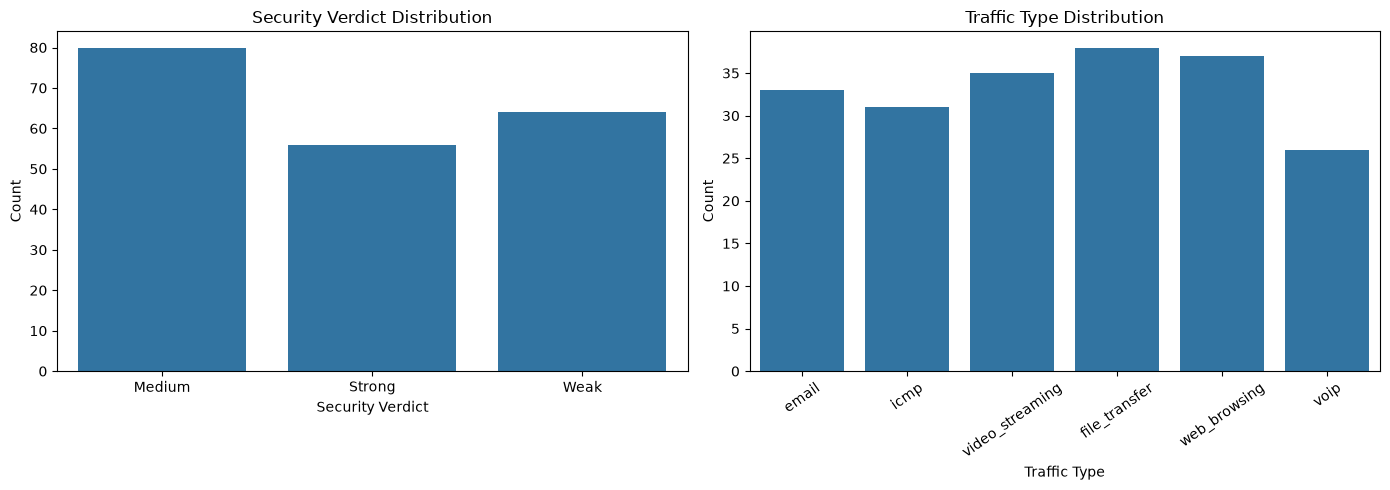

In [5]:
# ============================================================
# Cell 4: Class distributions
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(
    data=synthetic_df,
    x="security_verdict",
    ax=axes[0]
)
axes[0].set_title("Security Verdict Distribution")
axes[0].set_xlabel("Security Verdict")
axes[0].set_ylabel("Count")

sns.countplot(
    data=synthetic_df,
    x="traffic_type",
    ax=axes[1]
)
axes[1].set_title("Traffic Type Distribution")
axes[1].set_xlabel("Traffic Type")
axes[1].set_ylabel("Count")
axes[1].tick_params(axis="x", rotation=35)

plt.tight_layout()
plt.show()

In [6]:
# ============================================================
# Cell 6: Preprocessing helper
# ============================================================

# Features to use for the traffic type classifier
TRAFFIC_FEATURES = [
    "mode",
    "ip_version",
    "encryption_algo",
    "dh_group",
    "pfs",
    "avg_packet_size_bytes",
    "packet_rate_per_sec",
    "session_duration_sec",
    "burstiness_index",
    "ike_handshake_time_ms"
]


CATEGORICAL_FEATURES = [
    "mode",
    "ip_version",
    "encryption_algo",
    "dh_group",
    "pfs"
]

NUMERIC_FEATURES = [
    "avg_packet_size_bytes",
    "packet_rate_per_sec",
    "session_duration_sec",
    "burstiness_index",
    "ike_handshake_time_ms"
]


def build_preprocessor(feature_list):
    categorical = [
        col for col in CATEGORICAL_FEATURES
        if col in feature_list
    ]

    numeric = [
        col for col in NUMERIC_FEATURES
        if col in feature_list
    ]

    return ColumnTransformer(
        transformers=[
            (
                "categorical",
                OneHotEncoder(
                    handle_unknown="ignore",
                    sparse_output=False
                ),
                categorical
            ),
            (
                "numeric",
                StandardScaler(),
                numeric
            )
        ],
        remainder="drop"
    )


# Features for Traffic Type classifier (Model 1)
TRAFFIC_FEATURES = [
    "mode",
    "ip_version",
    "encryption_algo",
    "dh_group",
    "pfs",
    "avg_packet_size_bytes",
    "packet_rate_per_sec",
    "session_duration_sec",
    "burstiness_index",
    "ike_handshake_time_ms"
]

# Features for Security Verdict classifier (Model 2)
SECURITY_FEATURES = [
    "mode",
    "ip_version",
    "encryption_algo",
    "dh_group",
    "pfs",
    "avg_packet_size_bytes",
    "packet_rate_per_sec",
    "session_duration_sec",
    "burstiness_index",
    "ike_handshake_time_ms"
]

# Features for Risk Score regressor (Model 3)
RISK_FEATURES = [
    "mode",
    "ip_version",
    "encryption_algo",
    "dh_group",
    "pfs",
    "avg_packet_size_bytes",
    "packet_rate_per_sec",
    "session_duration_sec",
    "burstiness_index",
    "ike_handshake_time_ms"
]

print("Preprocessing configuration ready.")

Preprocessing configuration ready.


# Model 1

In [7]:
# ============================================================
# Cell 7: Traffic classifier data
# ============================================================

X_traffic = synthetic_df[TRAFFIC_FEATURES].copy()
y_traffic = synthetic_df["traffic_type"].copy()

X_train_t, X_val_t, y_train_t, y_val_t = train_test_split(
    X_traffic,
    y_traffic,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y_traffic
)

print("Training samples :", len(X_train_t))
print("Validation samples:", len(X_val_t))

Training samples : 160
Validation samples: 40


In [8]:
# ============================================================
# Cell 8: Train Traffic Type classifier
# ============================================================

traffic_preprocessor = build_preprocessor(TRAFFIC_FEATURES)

traffic_model = Pipeline(
    steps=[
        (
            "preprocessor",
            traffic_preprocessor
        ),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=400,
                max_depth=None,
                min_samples_split=2,
                min_samples_leaf=1,
                class_weight="balanced",
                random_state=RANDOM_STATE,
                n_jobs=-1
            )
        )
    ]
)

traffic_model.fit(X_train_t, y_train_t)

print("Traffic classifier trained.")

Traffic classifier trained.


In [9]:
# ============================================================
# Cell 9: Evaluate Traffic Type classifier
# ============================================================

traffic_pred = traffic_model.predict(X_val_t)

traffic_accuracy = accuracy_score(y_val_t, traffic_pred)
traffic_f1 = f1_score(
    y_val_t,
    traffic_pred,
    average="macro"
)

print(f"Validation Accuracy : {traffic_accuracy:.4f}")
print(f"Validation Macro F1 : {traffic_f1:.4f}")

print("\nClassification Report:\n")
print(
    classification_report(
        y_val_t,
        traffic_pred,
        digits=4
    )
)

Validation Accuracy : 0.9500
Validation Macro F1 : 0.9534

Classification Report:

                 precision    recall  f1-score   support

          email     1.0000    0.8571    0.9231         7
  file_transfer     0.8889    1.0000    0.9412         8
           icmp     1.0000    1.0000    1.0000         6
video_streaming     1.0000    0.8571    0.9231         7
           voip     1.0000    1.0000    1.0000         5
   web_browsing     0.8750    1.0000    0.9333         7

       accuracy                         0.9500        40
      macro avg     0.9606    0.9524    0.9534        40
   weighted avg     0.9559    0.9500    0.9496        40



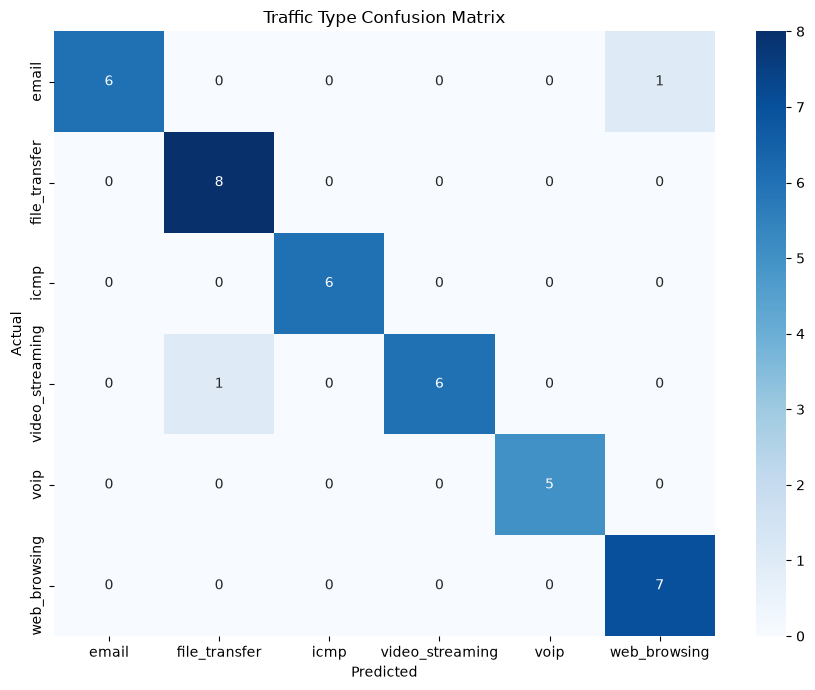

In [10]:
# ============================================================
# Cell 10: Traffic confusion matrix
# ============================================================

cm = confusion_matrix(
    y_val_t,
    traffic_pred,
    labels=traffic_model.classes_
)

plt.figure(figsize=(9, 7))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=traffic_model.classes_,
    yticklabels=traffic_model.classes_
)

plt.title("Traffic Type Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

# Model 2

In [11]:
# ============================================================
# Cell 11: Security classifier data
# ============================================================

X_security = synthetic_df[SECURITY_FEATURES].copy()
y_security = synthetic_df["security_verdict"].copy()

X_train_s, X_val_s, y_train_s, y_val_s = train_test_split(
    X_security,
    y_security,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y_security
)

print("Training samples :", len(X_train_s))
print("Validation samples:", len(X_val_s))

Training samples : 160
Validation samples: 40


In [12]:
# ============================================================
# Cell 12: Train Security Verdict classifier
# ============================================================

security_preprocessor = build_preprocessor(SECURITY_FEATURES)

security_model = Pipeline(
    steps=[
        (
            "preprocessor",
            security_preprocessor
        ),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=500,
                max_depth=None,
                min_samples_split=2,
                min_samples_leaf=1,
                class_weight="balanced",
                random_state=RANDOM_STATE,
                n_jobs=-1
            )
        )
    ]
)

security_model.fit(X_train_s, y_train_s)

print("Security classifier trained.")

Security classifier trained.


In [13]:
# ============================================================
# Cell 13: Evaluate Security Verdict classifier
# ============================================================

security_pred = security_model.predict(X_val_s)

security_accuracy = accuracy_score(
    y_val_s,
    security_pred
)

security_f1 = f1_score(
    y_val_s,
    security_pred,
    average="macro"
)

print(f"Validation Accuracy : {security_accuracy:.4f}")
print(f"Validation Macro F1 : {security_f1:.4f}")

print("\nClassification Report:\n")
print(
    classification_report(
        y_val_s,
        security_pred,
        digits=4
    )
)

Validation Accuracy : 0.9500
Validation Macro F1 : 0.9526

Classification Report:

              precision    recall  f1-score   support

      Medium     0.8889    1.0000    0.9412        16
      Strong     1.0000    1.0000    1.0000        11
        Weak     1.0000    0.8462    0.9167        13

    accuracy                         0.9500        40
   macro avg     0.9630    0.9487    0.9526        40
weighted avg     0.9556    0.9500    0.9494        40



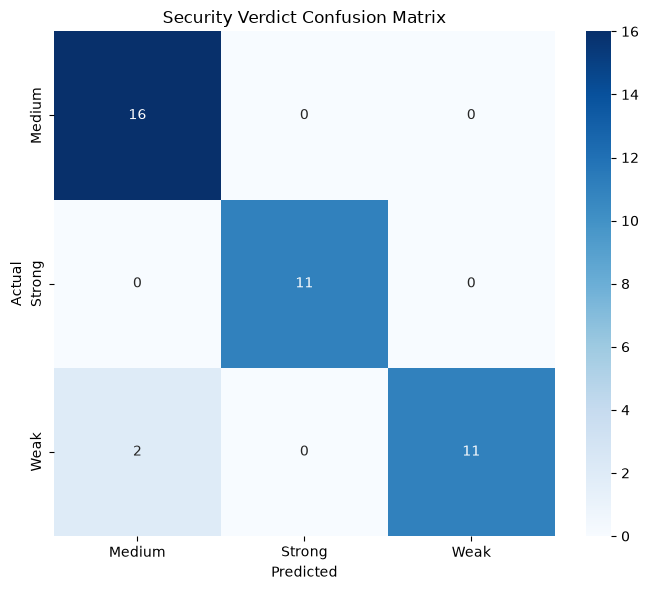

In [14]:
# ============================================================
# Cell 14: Security confusion matrix
# ============================================================

cm = confusion_matrix(
    y_val_s,
    security_pred,
    labels=security_model.classes_
)

plt.figure(figsize=(7, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=security_model.classes_,
    yticklabels=security_model.classes_
)

plt.title("Security Verdict Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

# Model 3

In [15]:
# ============================================================
# Cell 15: Risk score data
# ============================================================

X_risk = synthetic_df[RISK_FEATURES].copy()
y_risk = synthetic_df["risk_score"].copy()

X_train_r, X_val_r, y_train_r, y_val_r = train_test_split(
    X_risk,
    y_risk,
    test_size=0.20,
    random_state=RANDOM_STATE
)

print("Training samples :", len(X_train_r))
print("Validation samples:", len(X_val_r))

Training samples : 160
Validation samples: 40


In [16]:
# ============================================================
# Cell 16: Train Risk Score regressor
# ============================================================

risk_preprocessor = build_preprocessor(RISK_FEATURES)

risk_model = Pipeline(
    steps=[
        (
            "preprocessor",
            risk_preprocessor
        ),
        (
            "regressor",
            RandomForestRegressor(
                n_estimators=500,
                max_depth=None,
                min_samples_split=2,
                min_samples_leaf=1,
                random_state=RANDOM_STATE,
                n_jobs=-1
            )
        )
    ]
)

risk_model.fit(X_train_r, y_train_r)

print("Risk regression model trained.")

Risk regression model trained.


In [17]:
# ============================================================
# Cell 17: Evaluate Risk Score regression
# ============================================================

risk_pred = risk_model.predict(X_val_r)

mae = mean_absolute_error(
    y_val_r,
    risk_pred
)

rmse = np.sqrt(
    mean_squared_error(
        y_val_r,
        risk_pred
    )
)

r2 = r2_score(
    y_val_r,
    risk_pred
)

print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R²   : {r2:.4f}")

MAE  : 1.0904
RMSE : 1.3515
R²   : 0.7611


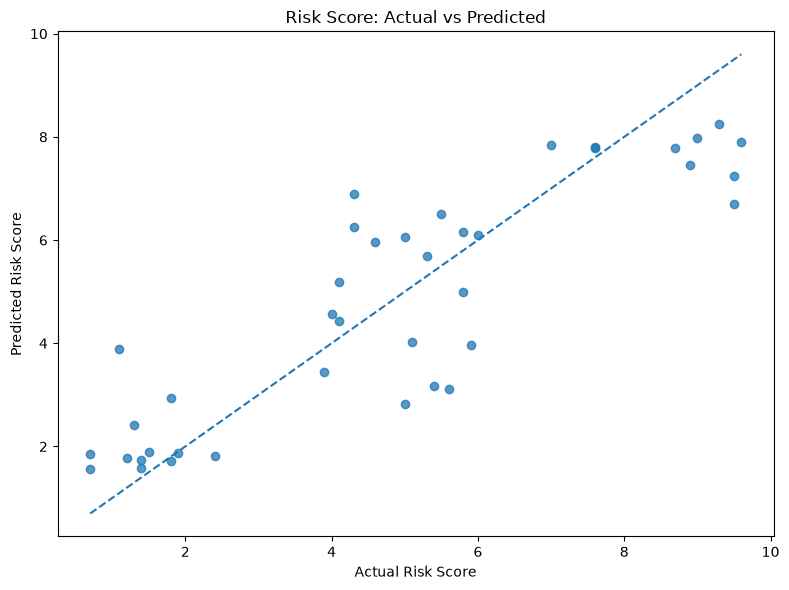

In [18]:
# ============================================================
# Cell 18: Actual vs Predicted Risk Score
# ============================================================

plt.figure(figsize=(8, 6))

plt.scatter(
    y_val_r,
    risk_pred,
    alpha=0.75
)

min_value = min(
    y_val_r.min(),
    risk_pred.min()
)

max_value = max(
    y_val_r.max(),
    risk_pred.max()
)

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("Actual Risk Score")
plt.ylabel("Predicted Risk Score")
plt.title("Risk Score: Actual vs Predicted")
plt.tight_layout()
plt.show()

# Testing

In [19]:
# ============================================================
# Cell 19: External test - Weak tunnels
# ============================================================

weak_traffic_pred = traffic_model.predict(
    weak_df[TRAFFIC_FEATURES]
)

weak_security_pred = security_model.predict(
    weak_df[SECURITY_FEATURES]
)

weak_risk_pred = risk_model.predict(
    weak_df[RISK_FEATURES]
)

weak_results = weak_df[
    [
        "sample_id",
        "security_verdict",
        "risk_score",
        "traffic_type"
    ]
].copy()

weak_results["predicted_traffic"] = weak_traffic_pred
weak_results["predicted_security"] = weak_security_pred
weak_results["predicted_risk"] = weak_risk_pred.round(2)

weak_results

,sample_id,security_verdict,risk_score,traffic_type,predicted_traffic,predicted_security,predicted_risk
0,WEAK001,Weak,8.4,file_transfer,file_transfer,Weak,8.38
1,WEAK002,Weak,9.0,icmp,icmp,Weak,8.47
2,WEAK003,Weak,9.8,file_transfer,file_transfer,Weak,8.26
3,WEAK004,Weak,8.9,web_browsing,web_browsing,Weak,7.98
4,WEAK005,Weak,9.4,icmp,icmp,Weak,8.55
5,WEAK006,Weak,8.2,icmp,icmp,Weak,8.62
6,WEAK007,Weak,8.5,email,email,Weak,8.02
7,WEAK008,Weak,9.6,web_browsing,web_browsing,Weak,7.94
8,WEAK009,Weak,9.2,video_streaming,video_streaming,Weak,7.82
9,WEAK010,Weak,9.5,web_browsing,web_browsing,Weak,8.69


In [20]:
# ============================================================
# Cell 20: Weak external evaluation
# ============================================================

weak_security_accuracy = accuracy_score(
    weak_df["security_verdict"],
    weak_security_pred
)

weak_security_f1 = f1_score(
    weak_df["security_verdict"],
    weak_security_pred,
    average="macro"
)

weak_traffic_accuracy = accuracy_score(
    weak_df["traffic_type"],
    weak_traffic_pred
)

weak_traffic_f1 = f1_score(
    weak_df["traffic_type"],
    weak_traffic_pred,
    average="macro"
)

weak_mae = mean_absolute_error(
    weak_df["risk_score"],
    weak_risk_pred
)

print("WEAK TUNNEL EXTERNAL TEST")
print("=" * 40)

print(
    f"Security Accuracy : {weak_security_accuracy:.4f}"
)

print(
    f"Security Macro F1 : {weak_security_f1:.4f}"
)

print(
    f"Traffic Accuracy  : {weak_traffic_accuracy:.4f}"
)

print(
    f"Traffic Macro F1  : {weak_traffic_f1:.4f}"
)

print(
    f"Risk MAE          : {weak_mae:.4f}"
)

WEAK TUNNEL EXTERNAL TEST
Security Accuracy : 1.0000
Security Macro F1 : 1.0000
Traffic Accuracy  : 0.9200
Traffic Macro F1  : 0.9333
Risk MAE          : 0.8376


In [21]:
# ============================================================
# Cell 21: External test - Strong tunnels
# ============================================================

strong_traffic_pred = traffic_model.predict(
    strong_df[TRAFFIC_FEATURES]
)

strong_security_pred = security_model.predict(
    strong_df[SECURITY_FEATURES]
)

strong_risk_pred = risk_model.predict(
    strong_df[RISK_FEATURES]
)

strong_results = strong_df[
    [
        "sample_id",
        "security_verdict",
        "risk_score",
        "traffic_type"
    ]
].copy()

strong_results["predicted_traffic"] = strong_traffic_pred
strong_results["predicted_security"] = strong_security_pred
strong_results["predicted_risk"] = strong_risk_pred.round(2)

strong_results

,sample_id,security_verdict,risk_score,traffic_type,predicted_traffic,predicted_security,predicted_risk
0,STR001,Strong,1.0,voip,voip,Strong,1.55
1,STR002,Strong,0.6,file_transfer,file_transfer,Strong,1.86
2,STR003,Strong,1.0,file_transfer,file_transfer,Strong,1.90
3,STR004,Strong,2.0,web_browsing,web_browsing,Strong,1.42
4,STR005,Strong,1.2,voip,voip,Strong,1.97
5,STR006,Strong,1.1,web_browsing,web_browsing,Strong,1.58
6,STR007,Strong,1.3,file_transfer,file_transfer,Strong,3.13
7,STR008,Strong,1.5,icmp,icmp,Strong,2.11
8,STR009,Strong,0.6,web_browsing,web_browsing,Strong,1.73
9,STR010,Strong,0.8,file_transfer,file_transfer,Strong,1.92


In [22]:
# ============================================================
# Cell 22: Strong external evaluation
# ============================================================

strong_security_accuracy = accuracy_score(
    strong_df["security_verdict"],
    strong_security_pred
)

strong_security_f1 = f1_score(
    strong_df["security_verdict"],
    strong_security_pred,
    average="macro"
)

strong_traffic_accuracy = accuracy_score(
    strong_df["traffic_type"],
    strong_traffic_pred
)

strong_traffic_f1 = f1_score(
    strong_df["traffic_type"],
    strong_traffic_pred,
    average="macro"
)

strong_mae = mean_absolute_error(
    strong_df["risk_score"],
    strong_risk_pred
)

print("STRONG TUNNEL EXTERNAL TEST")
print("=" * 40)

print(
    f"Security Accuracy : {strong_security_accuracy:.4f}"
)

print(
    f"Security Macro F1 : {strong_security_f1:.4f}"
)

print(
    f"Traffic Accuracy  : {strong_traffic_accuracy:.4f}"
)

print(
    f"Traffic Macro F1  : {strong_traffic_f1:.4f}"
)

print(
    f"Risk MAE          : {strong_mae:.4f}"
)

STRONG TUNNEL EXTERNAL TEST
Security Accuracy : 1.0000
Security Macro F1 : 1.0000
Traffic Accuracy  : 0.9600
Traffic Macro F1  : 0.9418
Risk MAE          : 0.9339


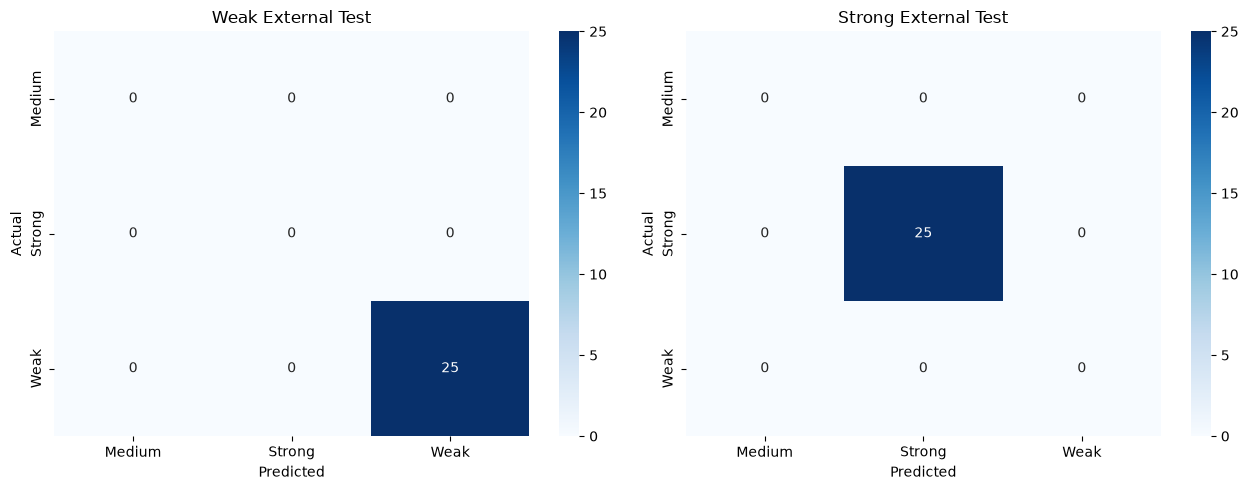

In [23]:
# ============================================================
# Cell 23: External security confusion matrices
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

weak_cm = confusion_matrix(
    weak_df["security_verdict"],
    weak_security_pred,
    labels=security_model.classes_
)

strong_cm = confusion_matrix(
    strong_df["security_verdict"],
    strong_security_pred,
    labels=security_model.classes_
)

sns.heatmap(
    weak_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=security_model.classes_,
    yticklabels=security_model.classes_,
    ax=axes[0]
)

axes[0].set_title("Weak External Test")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

sns.heatmap(
    strong_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=security_model.classes_,
    yticklabels=security_model.classes_,
    ax=axes[1]
)

axes[1].set_title("Strong External Test")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

plt.tight_layout()
plt.show()

In [24]:
# ============================================================
# Cell 24: Prediction confidence
# ============================================================

def get_prediction_confidence(model, X):
    probabilities = model.predict_proba(X)
    return probabilities.max(axis=1)


weak_security_conf = get_prediction_confidence(
    security_model,
    weak_df[SECURITY_FEATURES]
)

strong_security_conf = get_prediction_confidence(
    security_model,
    strong_df[SECURITY_FEATURES]
)

weak_results["security_confidence"] = (
    weak_security_conf * 100
).round(2)

strong_results["security_confidence"] = (
    strong_security_conf * 100
).round(2)

print("Weak predictions:")
display(weak_results.head(10))

print("\nStrong predictions:")
display(strong_results.head(10))

Weak predictions:


,sample_id,security_verdict,risk_score,traffic_type,predicted_traffic,predicted_security,predicted_risk,security_confidence
0,WEAK001,Weak,8.4,file_transfer,file_transfer,Weak,8.38,91.4
1,WEAK002,Weak,9.0,icmp,icmp,Weak,8.47,81.4
2,WEAK003,Weak,9.8,file_transfer,file_transfer,Weak,8.26,83.4
3,WEAK004,Weak,8.9,web_browsing,web_browsing,Weak,7.98,56.2
4,WEAK005,Weak,9.4,icmp,icmp,Weak,8.55,79.6
5,WEAK006,Weak,8.2,icmp,icmp,Weak,8.62,93.0
6,WEAK007,Weak,8.5,email,email,Weak,8.02,78.4
7,WEAK008,Weak,9.6,web_browsing,web_browsing,Weak,7.94,61.8
8,WEAK009,Weak,9.2,video_streaming,video_streaming,Weak,7.82,55.2
9,WEAK010,Weak,9.5,web_browsing,web_browsing,Weak,8.69,90.2



Strong predictions:


,sample_id,security_verdict,risk_score,traffic_type,predicted_traffic,predicted_security,predicted_risk,security_confidence
0,STR001,Strong,1.0,voip,voip,Strong,1.55,81.2
1,STR002,Strong,0.6,file_transfer,file_transfer,Strong,1.86,81.4
2,STR003,Strong,1.0,file_transfer,file_transfer,Strong,1.90,77.4
3,STR004,Strong,2.0,web_browsing,web_browsing,Strong,1.42,83.0
4,STR005,Strong,1.2,voip,voip,Strong,1.97,66.2
5,STR006,Strong,1.1,web_browsing,web_browsing,Strong,1.58,72.8
6,STR007,Strong,1.3,file_transfer,file_transfer,Strong,3.13,61.6
7,STR008,Strong,1.5,icmp,icmp,Strong,2.11,75.0
8,STR009,Strong,0.6,web_browsing,web_browsing,Strong,1.73,80.4
9,STR010,Strong,0.8,file_transfer,file_transfer,Strong,1.92,73.6


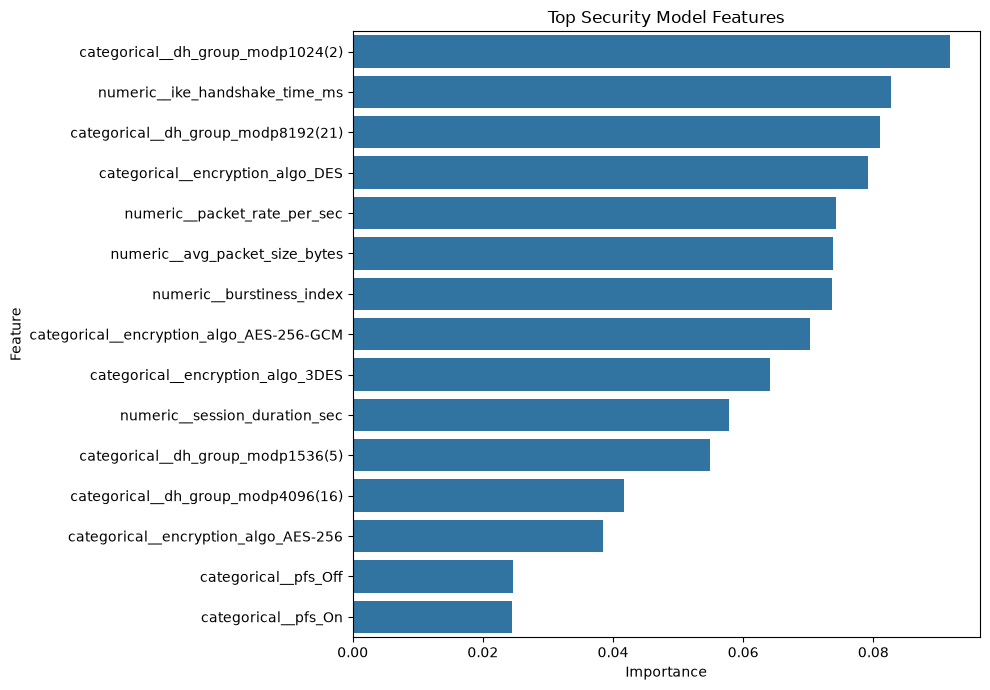

,feature,importance
8,categorical__dh_group_modp1024(2),0.091797
19,numeric__ike_handshake_time_ms,0.082677
12,categorical__dh_group_modp8192(21),0.080996
7,categorical__encryption_algo_DES,0.079164
16,numeric__packet_rate_per_sec,0.074302
15,numeric__avg_packet_size_bytes,0.073761
18,numeric__burstiness_index,0.073691
6,categorical__encryption_algo_AES-256-GCM,0.070280
3,categorical__encryption_algo_3DES,0.064109
17,numeric__session_duration_sec,0.057890


In [25]:
# ============================================================
# Cell 25: Security model feature importance
# ============================================================

preprocessor = security_model.named_steps["preprocessor"]
classifier = security_model.named_steps["classifier"]

feature_names = preprocessor.get_feature_names_out()

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": classifier.feature_importances_
})

importance_df = importance_df.sort_values(
    "importance",
    ascending=False
).head(15)

plt.figure(figsize=(10, 7))

sns.barplot(
    data=importance_df,
    x="importance",
    y="feature"
)

plt.title("Top Security Model Features")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

importance_df

In [26]:
# ============================================================
# Cell 26: Save trained models
# ============================================================

joblib.dump(
    traffic_model,
    "../models/traffic_classifier.joblib"
)

joblib.dump(
    security_model,
    "../models/security_classifier.joblib"
)

joblib.dump(
    risk_model,
    "../models/risk_regressor.joblib"
)

print("Models saved successfully.")

Models saved successfully.


# Demo


In [27]:
# ============================================================
# Cell 27: TunnelScope AI demo
# ============================================================

def analyze_tunnel(row):
    """
    Run all three TunnelScope prototype models
    on a single tunnel record.
    """

    row_df = pd.DataFrame([row])

    traffic_input = row_df[TRAFFIC_FEATURES]
    security_input = row_df[SECURITY_FEATURES]
    risk_input = row_df[RISK_FEATURES]

    traffic_prediction = traffic_model.predict(
        traffic_input
    )[0]

    traffic_confidence = (
        traffic_model.predict_proba(
            traffic_input
        ).max() * 100
    )

    security_prediction = security_model.predict(
        security_input
    )[0]

    security_confidence = (
        security_model.predict_proba(
            security_input
        ).max() * 100
    )

    risk_prediction = risk_model.predict(
        risk_input
    )[0]

    print("=" * 55)
    print("              TUNNELSCOPE AI")
    print("=" * 55)

    print(f"Traffic Type       : {traffic_prediction}")
    print(f"Traffic Confidence : {traffic_confidence:.2f}%")

    print()

    print(f"Security Verdict   : {security_prediction}")
    print(f"Security Confidence: {security_confidence:.2f}%")

    print()

    print(f"Predicted Risk     : {risk_prediction:.2f}")

    print("=" * 55)

    return {
        "traffic_type": traffic_prediction,
        "traffic_confidence": round(traffic_confidence, 2),
        "security_verdict": security_prediction,
        "security_confidence": round(security_confidence, 2),
        "predicted_risk": round(risk_prediction, 2)
    }

In [40]:
# ============================================================
# Cell 28: TunnelScope AI Graph
# ============================================================

result = analyze_tunnel(
    strong_df.iloc[0].to_dict()
)

import matplotlib.pyplot as plt

labels = [
    "Traffic Confidence",
    "Security Confidence",
    "Predicted Risk"
]

values = [
    result["traffic_confidence"],
    result["security_confidence"],
    result["predicted_risk"]
]

plt.figure(figsize=(8, 5))

bars = plt.bar(labels, values)

plt.title("TunnelScope AI Analysis - Strong Tunnel")
plt.ylabel("Score / Confidence")
plt.ylim(0, 100)

for bar, value in zip(bars, values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        f"{value:.2f}",
        ha="center"
    )

plt.tight_layout()
plt.show()

ValueError: columns are missing: {'pfs', 'dh_group', 'encryption_algo'}

In [29]:
# Weak tunnel demonstration
analyze_tunnel(
    weak_df.iloc[0].to_dict()
)

              TUNNELSCOPE AI
Traffic Type       : file_transfer
Traffic Confidence : 77.50%

Security Verdict   : Weak
Security Confidence: 91.40%

Predicted Risk     : 8.38


{'traffic_type': 'file_transfer',
 'traffic_confidence': np.float64(77.5),
 'security_verdict': 'Weak',
 'security_confidence': np.float64(91.4),
 'predicted_risk': np.float64(8.38)}

PCAP
 ↓
IKE/ESP parser
 ↓
extract observable features
 ↓
ML models
 ↓
security assessment

## save to onnx


In [30]:
# ============================================================
# Export trained models to ONNX
# ============================================================

from skl2onnx import to_onnx
from skl2onnx.common.data_types import FloatTensorType, StringTensorType

In [31]:
# ============================================================
# ONNX input definition
# ============================================================

def make_initial_types(feature_list):
    initial_types = []

    for col in feature_list:
        if col in CATEGORICAL_FEATURES:
            initial_types.append(
                (
                    col,
                    StringTensorType([None, 1])
                )
            )
        elif col in NUMERIC_FEATURES:
            initial_types.append(
                (
                    col,
                    FloatTensorType([None, 1])
                )
            )
        else:
            raise ValueError(
                f"Unknown feature type: {col}"
            )

    return initial_types

In [32]:
traffic_initial_types = make_initial_types(
    TRAFFIC_FEATURES
)

security_initial_types = make_initial_types(
    SECURITY_FEATURES
)

risk_initial_types = make_initial_types(
    RISK_FEATURES
)

In [33]:
# ============================================================
# Export Traffic Classifier
# ============================================================

traffic_onnx = to_onnx(
    traffic_model,
    X_train_t.iloc[:1],
    target_opset=17
)

with open(
    "../models/traffic_classifier.onnx",
    "wb"
) as f:
    f.write(
        traffic_onnx.SerializeToString()
    )

print("Traffic classifier exported.")

Traffic classifier exported.


In [34]:
# ============================================================
# Export Security Classifier
# ============================================================

security_onnx = to_onnx(
    security_model,
    initial_types=security_initial_types,
    target_opset=17
)

with open(
    "../models/security_classifier.onnx",
    "wb"
) as f:
    f.write(
        security_onnx.SerializeToString()
    )

print("Security classifier exported.")

Security classifier exported.


In [35]:
# ============================================================
# Export Risk Regressor
# ============================================================

risk_onnx = to_onnx(
    risk_model,
    initial_types=risk_initial_types,
    target_opset=17
)

with open(
    "../models/risk_regressor.onnx",
    "wb"
) as f:
    f.write(
        risk_onnx.SerializeToString()
    )

print("Risk regressor exported.")

Risk regressor exported.


In [36]:

import onnxruntime as ort

print(ort.__version__)
session = ort.InferenceSession(
    "../models/security_classifier.onnx",
    providers=["CPUExecutionProvider"]
)

for inp in session.get_inputs():
    print(
        inp.name,
        inp.type,
        inp.shape
    )

1.29.0
mode tensor(string) [None, 1]
ip_version tensor(string) [None, 1]
encryption_algo tensor(string) [None, 1]
dh_group tensor(string) [None, 1]
pfs tensor(string) [None, 1]
avg_packet_size_bytes tensor(float) [None, 1]
packet_rate_per_sec tensor(float) [None, 1]
session_duration_sec tensor(float) [None, 1]
burstiness_index tensor(float) [None, 1]
ike_handshake_time_ms tensor(float) [None, 1]


In [37]:

import joblib

model = joblib.load("../models/security_classifier.joblib")
print(model)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('categorical',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['mode', 'ip_version',
                                                   'encryption_algo',
                                                   'dh_group', 'pfs']),
                                                 ('numeric', StandardScaler(),
                                                  ['avg_packet_size_bytes',
                                                   'packet_rate_per_sec',
                                                   'session_duration_sec',
                                                   'burstiness_index',
                                                   'ike_handshake_time_ms'])])),
                ('classifier',
                 RandomFo

In [38]:
import joblib
import pandas as pd

# Load trained models
traffic_model = joblib.load("../models/traffic_classifier.joblib")
security_model = joblib.load("../models/security_classifier.joblib")
risk_model = joblib.load("../models/risk_regressor.joblib")

TRAFFIC_FEATURES = [
    "mode",
    "ip_version",
    "avg_packet_size_bytes",
    "packet_rate_per_sec",
    "session_duration_sec",
    "burstiness_index",
    "ike_handshake_time_ms"
]

SECURITY_FEATURES = [
    "mode",
    "encryption_algo",
    "dh_group",
    "pfs",
    "ip_version",
    "avg_packet_size_bytes",
    "packet_rate_per_sec",
    "session_duration_sec",
    "burstiness_index",
    "ike_handshake_time_ms"
]

RISK_FEATURES = SECURITY_FEATURES.copy()


def predict_tunnel(data):
    """
    Give one tunnel's feature data and get
    traffic type, security verdict and risk score.
    """

    if isinstance(data, dict):
        data = pd.DataFrame([data])

    traffic_input = data[TRAFFIC_FEATURES]
    security_input = data[SECURITY_FEATURES]
    risk_input = data[RISK_FEATURES]

    traffic_prediction = traffic_model.predict(
        traffic_input
    )[0]

    security_prediction = security_model.predict(
        security_input
    )[0]

    risk_prediction = risk_model.predict(
        risk_input
    )[0]

    return {
        "traffic_type": traffic_prediction,
        "security_verdict": security_prediction,
        "risk_score": round(float(risk_prediction), 2)
    }

In [39]:
result = predict_tunnel(
    strong_df.iloc[0].to_dict()
)

print(result)

ValueError: columns are missing: {'pfs', 'dh_group', 'encryption_algo'}